# Deep Learning for Sentiment Analysis

This notebook implements and evaluates multiple deep learning architectures for multiclass sentiment classification on the Amazon Reviews dataset.

Unlike traditional machine learning models that rely on sparse vector representations such as TF-IDF, deep learning models learn dense semantic representations of text through trainable embedding layers and sequential neural network architectures.

The preprocessing and feature engineering pipeline—including tokenization, sequence generation, padding, and label encoding—was completed in the previous notebook. Here, those saved artifacts are loaded to ensure a fully reproducible workflow.

The architectures evaluated in this notebook include:

- Artificial Neural Network (ANN)
- Long Short-Term Memory (LSTM)
- Bidirectional LSTM
- Gated Recurrent Unit (GRU)

The best-performing model will be selected based on classification performance and later compared with a Transformer-based model.

## Imports

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU Ready:", tf.config.list_physical_devices("GPU"))

GPU Ready: []


In [1]:
# Core
import os
import time
import random
import warnings
import zipfile
import json
import shutil
import tempfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inline plotting (Jupyter only)
%matplotlib inline  

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Embedding,
    GlobalAveragePooling1D,
    LSTM,
    Bidirectional,
    GRU,
    SpatialDropout1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Sklearn metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss
)

# Warnings & seeds
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Load Artifacts

# New Section

In [2]:
DL_ARTIFACT_DIR = "artifacts/deep_learning"
X_train = np.load(f"{DL_ARTIFACT_DIR}/X_train_pad.npy")
X_test = np.load(f"{DL_ARTIFACT_DIR}/X_test_pad.npy")

y_train = np.load(f"{DL_ARTIFACT_DIR}/y_train.npy")
y_test = np.load(f"{DL_ARTIFACT_DIR}/y_test.npy")

tokenizer = joblib.load(f"{DL_ARTIFACT_DIR}/dl_tokenizer.pkl")
label_encoder = joblib.load(f"{DL_ARTIFACT_DIR}/dl_label_encoder.pkl")

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(539618, 128)
(134905, 128)
(539618,)
(134905,)


## Model Configuration

In [3]:
VOCAB_SIZE = 30000
MAX_SEQUENCE_LENGTH = 128
EMBEDDING_DIM = 128

NUM_CLASSES = 3

BATCH_SIZE = 512

EPOCHS = 30

LEARNING_RATE = 0.001

In [4]:
def plot_evaluation_curves(y_test, y_pred, y_prob, label_encoder, model_name="Model"):
    n_classes = len(label_encoder.classes_)
    class_names = label_encoder.classes_
    y_test_bin = np.eye(n_classes)[y_test]

    # ROC computation
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc["macro"] = auc(all_fpr, mean_tpr)

    # Create figure with corrected size
    fig = plt.figure(figsize=(15, 5))
    gs = fig.add_gridspec(1, 3, wspace=0.4)
    fig.suptitle(f"{model_name} Performance Evaluation", fontsize=14, fontweight="bold", y=1.02)

    # ROC Curves
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(all_fpr, mean_tpr, linewidth=2.5, label=f"Macro Avg (AUC={roc_auc['macro']:.3f})")
    for i in range(n_classes):
        ax1.plot(fpr[i], tpr[i], linewidth=2, label=f"{class_names[i]} ({roc_auc[i]:.3f})")
    ax1.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax1.set_title("ROC Curves", fontsize=11, fontweight="bold")
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.grid(alpha=0.3)
    ax1.legend(fontsize=7)

    # Confusion Matrix
    ax2 = fig.add_subplot(gs[0, 1])
    cm = confusion_matrix(y_test, y_pred)
    im = ax2.imshow(cm, cmap="Blues")
    ax2.set_title("Confusion Matrix", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Predicted Label")
    ax2.set_ylabel("True Label")
    ax2.set_xticks(np.arange(n_classes))
    ax2.set_yticks(np.arange(n_classes))
    ax2.set_xticklabels(class_names)
    ax2.set_yticklabels(class_names)

    threshold = cm.max() / 2
    for i in range(n_classes):
        for j in range(n_classes):
            ax2.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=8,
                     color="white" if cm[i, j] > threshold else "black")

    # Precision–Recall Curves
    ax3 = fig.add_subplot(gs[0, 2])
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
        ap = average_precision_score(y_test_bin[:, i], y_prob[:, i])
        ax3.plot(recall, precision, linewidth=2, label=f"{class_names[i]} (AP={ap:.3f})")
    ax3.set_title("Precision-Recall Curves", fontsize=11, fontweight="bold")
    ax3.set_xlabel("Recall")
    ax3.set_ylabel("Precision")
    ax3.grid(alpha=0.3)
    ax3.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    return roc_auc["macro"]


def evaluate_model(model, X_test, y_test, label_encoder, model_name="Model"):
    print("=" * 80)
    print(f"{model_name.upper()} EVALUATION")
    print("=" * 80)

    # Loss & Accuracy
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_accuracy:.4f}")

    # Predictions
    start = time.time()
    y_prob = model.predict(X_test, verbose=0)
    prediction_time = time.time() - start
    y_pred = np.argmax(y_prob, axis=1)

    # Classification Report
    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Extra important metrics
    f1 = f1_score(y_test, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    logloss = log_loss(y_test, y_prob)

    print(f"F1 Score (weighted) : {f1:.4f}")
    print(f"Matthews Corrcoef   : {mcc:.4f}")
    print(f"Cohen’s Kappa       : {kappa:.4f}")
    print(f"Log Loss            : {logloss:.4f}")

    # Curves
    roc_auc_macro = plot_evaluation_curves(
        y_test=y_test,
        y_pred=y_pred,
        y_prob=y_prob,
        label_encoder=label_encoder,
        model_name=model_name
    )

    return {
        "Model": model_name,
        "Loss": test_loss,
        "Accuracy": test_accuracy,
        "Prediction Time": prediction_time,
        "F1 Score": f1,
        "MCC": mcc,
        "Kappa": kappa,
        "Log Loss": logloss,
        "ROC AUC Macro": roc_auc_macro
    }


In [18]:
ann_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    ),

    GlobalAveragePooling1D(),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

ann_model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
ann_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 128, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,906,307 (14.90 MB)

 Trainable params: 3,906,307 (14.90 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8393 - loss: 0.4264 - val_accuracy: 0.8609 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8811 - loss: 0.3169 - val_accuracy: 0.8836 - val_loss: 0.3132 - learning_rate: 0.0010
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8874 - loss: 0.2997 - val_accuracy: 0.8853 - val_loss: 0.3049 - learning_rate: 0.0010
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8912 - loss: 0.2881 - val_accuracy: 0.8892 - val_loss: 0.2939 - learning_rate: 0.0010
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8943 - loss: 0.2793 - val_accuracy: 0.8897 - val_loss: 0.2939 - learning_rate: 0.0010
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8974 - loss: 0.2717 - val_accuracy: 0.8887 - val_loss: 0.3035 - learning_rate: 0.0010
Epoch 7/30
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8977 - loss: 0.2711

ANN EVALUATION
Test Loss     : 0.2929
Test Accuracy : 0.8885

Classification Report

              precision    recall  f1-score   support

    Negative       0.80      0.87      0.83     27966
     Neutral       0.54      0.31      0.40     10923
    Positive       0.94      0.96      0.95     96016

    accuracy                           0.89    134905
   macro avg       0.76      0.71      0.73    134905
weighted avg       0.88      0.89      0.88    134905



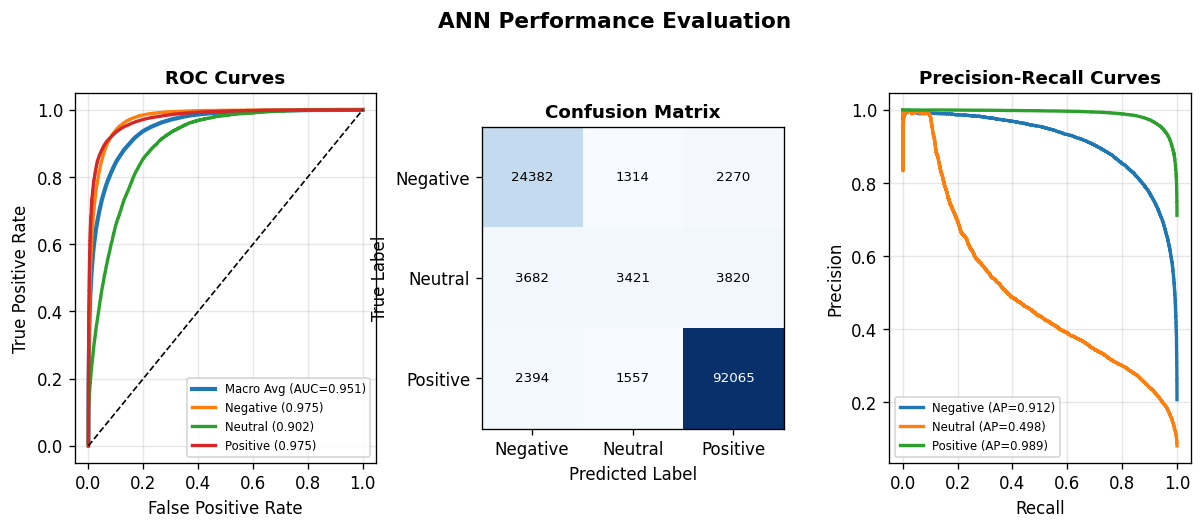

In [ ]:
ann_results = evaluate_model(
    model=ann_model,
    X_test=X_test,
    y_test=y_test,
    label_encoder=label_encoder,
    model_name="ANN"
)

In [20]:
# Define the LSTM model
lstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    ),
    SpatialDropout1D(0.2),
    LSTM(
        units=128,
        dropout=0.3,
        recurrent_dropout=0.3
    ),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

# Compile the model
lstm_model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
lstm_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 128, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 128, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,996,547 (15.25 MB)

 Trainable params: 3,996,547 (15.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 445s 517ms/step - accuracy: 0.7112 - loss: 0.7812 - val_accuracy: 0.7113 - val_loss: 0.7695 - learning_rate: 0.0010
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 433s 513ms/step - accuracy: 0.7118 - loss: 0.7722 - val_accuracy: 0.7113 - val_loss: 0.7706 - learning_rate: 0.0010
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.7203 - loss: 0.7465
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
844/844 ━━━━━━━━━━━━━━━━━━━━ 460s 535ms/step - accuracy: 0.7618 - loss: 0.6391 - val_accuracy: 0.8797 - val_loss: 0.3153 - learning_rate: 0.0010
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 431s 510ms/step - accuracy: 0.8828 - loss: 0.3094 - val_accuracy: 0.8931 - val_loss: 0.2872 - learning_rate: 5.0000e-04
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 429s 508ms/step - accuracy: 0.8920 - loss: 0.2831 - val_accuracy: 0.8957 - val_loss: 0.2776 - learning_rate: 5.0000e-04
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 446s 513ms/step - a

In [76]:
src = "models/lstm_model.keras"
dst = "models/lstm_model_patched.keras"

tmpdir = tempfile.mkdtemp()

with zipfile.ZipFile(src, "r") as z:
    z.extractall(tmpdir)

config_path = os.path.join(tmpdir, "config.json")

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

def remove_quantization(obj):
    if isinstance(obj, dict):
        obj.pop("quantization_config", None)
        for v in obj.values():
            remove_quantization(v)
    elif isinstance(obj, list):
        for v in obj:
            remove_quantization(v)

remove_quantization(config)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f)

with zipfile.ZipFile(dst, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(tmpdir):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, tmpdir)
            z.write(full_path, arcname)

shutil.rmtree(tmpdir)

print("Patched model saved to:", dst)

Patched model saved to: models/lstm_model_patched.keras


In [74]:
with zipfile.ZipFile("models/lstm_model_patched.keras", "r") as z:
    print(z.namelist())

['config.json', 'metadata.json', 'model.weights.h5']


In [73]:
lstm_model = load_model(
    "models/lstm_model_patched.keras",
    compile=True
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 128, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 128, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,989,643 (45.74 MB)

 Trainable params: 3,996,547 (15.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,993,096 (30.49 MB)

LSTM EVALUATION
Test Loss     : 0.2708
Test Accuracy : 0.9008

Classification Report

              precision    recall  f1-score   support

    Negative       0.84      0.87      0.86     27966
     Neutral       0.51      0.40      0.45     10923
    Positive       0.95      0.97      0.96     96016

    accuracy                           0.90    134905
   macro avg       0.77      0.75      0.76    134905
weighted avg       0.89      0.90      0.90    134905

F1 Score (weighted) : 0.8967
Matthews Corrcoef   : 0.7734
Cohen’s Kappa       : 0.7728
Log Loss            : 0.2708


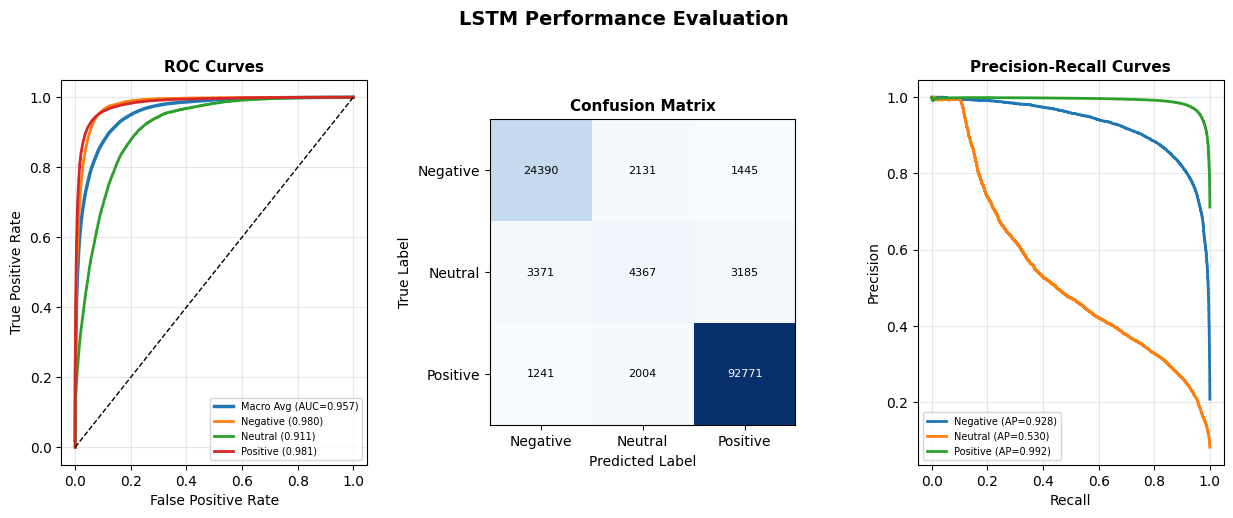

In [72]:
lstm_results = evaluate_model(
    model=lstm_model,
    X_test=X_test,
    y_test=y_test,
    label_encoder=label_encoder,
    model_name="LSTM"
)

In [ ]:
bilstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    ),

    SpatialDropout1D(0.2),

    Bidirectional(
        LSTM(
            128,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    ),

    Dense(128, activation="relu"),
    Dropout(0.4),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

bilstm_model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 749s 880ms/step - accuracy: 0.8772 - loss: 0.3331 - val_accuracy: 0.8960 - val_loss: 0.2754 - learning_rate: 0.0010
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 738s 875ms/step - accuracy: 0.8997 - loss: 0.2688 - val_accuracy: 0.9013 - val_loss: 0.2618 - learning_rate: 0.0010
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 736s 871ms/step - accuracy: 0.9069 - loss: 0.2480 - val_accuracy: 0.9035 - val_loss: 0.2546 - learning_rate: 0.0010
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 758s 890ms/step - accuracy: 0.9110 - loss: 0.2349 - val_accuracy: 0.9038 - val_loss: 0.2556 - learning_rate: 0.0010
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 754s 893ms/step - accuracy: 0.9150 - loss: 0.2245 - val_accuracy: 0.9045 - val_loss: 0.2564 - learning_rate: 0.0010
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step - accuracy: 0.9173 - loss: 0.2181
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
844/844 ━━━━━━━━━━━━━━━━━━━━ 753s 892ms/step - accuracy:

In [ ]:
bilstm_model.save(f"{MODEL_DIR}/bilstm_model.keras")

In [77]:
src = "models/bilstm_model.keras"
dst = "models/bilstm_model_patched.keras"

tmpdir = tempfile.mkdtemp()

with zipfile.ZipFile(src, "r") as z:
    z.extractall(tmpdir)

config_path = os.path.join(tmpdir, "config.json")

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

def remove_quantization(obj):
    if isinstance(obj, dict):
        obj.pop("quantization_config", None)
        for v in obj.values():
            remove_quantization(v)
    elif isinstance(obj, list):
        for v in obj:
            remove_quantization(v)

remove_quantization(config)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f)

with zipfile.ZipFile(dst, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(tmpdir):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, tmpdir)
            z.write(full_path, arcname)

shutil.rmtree(tmpdir)

print("Patched model saved to:", dst)

Patched model saved to: models/bilstm_model_patched.keras


In [83]:
with zipfile.ZipFile("models/bilstm_model_patched.keras", "r") as z:
    print(z.namelist())

['config.json', 'metadata.json', 'model.weights.h5']


In [84]:
bilstm_model = load_model(
    "models/bilstm_model_patched.keras",
    compile=True
)

bilstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 128, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 128, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,433,547 (47.43 MB)

 Trainable params: 4,144,515 (15.81 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,289,032 (31.62 MB)

BILSTM EVALUATION
Test Loss     : 0.2568
Test Accuracy : 0.9028

Classification Report

              precision    recall  f1-score   support

    Negative       0.82      0.89      0.86     27966
     Neutral       0.57      0.35      0.43     10923
    Positive       0.95      0.97      0.96     96016

    accuracy                           0.90    134905
   macro avg       0.78      0.74      0.75    134905
weighted avg       0.89      0.90      0.90    134905

F1 Score (weighted) : 0.8953
Matthews Corrcoef   : 0.7770
Cohen’s Kappa       : 0.7753
Log Loss            : 0.2568


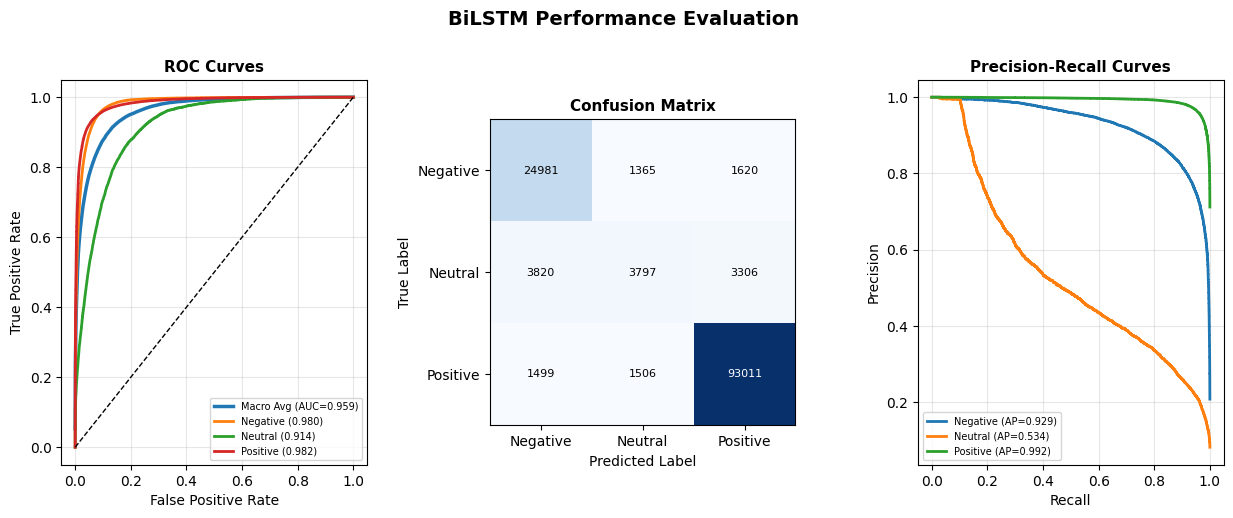

In [85]:
bilstm_results = evaluate_model(
    model=bilstm_model,
    X_test=X_test,
    y_test=y_test,
    label_encoder=label_encoder,
    model_name="BiLSTM"
)